# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Arya Ivan Ghally
- **Email:** cdcc009d6y2672@student.devacademy.id
- **ID Dicoding:** cdcc009d6y2672

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana perbandingan penyebaran partikel halus (PM2.5) pada hari tanpa hujan dan hari dengan curah hujan tinggi?
- Pertanyaan 2: Pada jam berapa terjadi puncak konsentrasi NO2 tertinggi secara konsisten di stasiun kategori urban?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Membuat style agar visualisasi seragam dan profesional
sns.set(style = "ticks")

## Data Wrangling

### Gathering Data

In [2]:
#List semua File CSV
path = "./"
files = [f for f in os.listdir(path) if f.startswith('PRSA_Data')]

#Menggabungkan semua stasiun dalam satu DataFrame
all_df = []
for file in files:
  temp_df = pd.read_csv(file)
  all_df.append(temp_df)

main_df = pd.concat(all_df, ignore_index=True)
main_df.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


**Insight:**
- Dari 12 stasiun pemantau kualitas udara semua datanya  digabungkan menjadi dataset tunggal


### Assessing Data

In [3]:
#Info dasar
main_df.info()

#Memeriksa missing value
print("\nMissing Values:\n",main_df.isna().sum())

#Memeriksa duplikasi
print("\nJumlah duplikasi: ",main_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB

Missing Values:
 No             0
year      

**Insight:**
- Ditemukan sejumlah missing values pada parameter polutan dan cuaca. Tidak ditemukan baris data yang duplikat.

### Cleaning Data

In [4]:
#1. Menangani missing values dengan interpolasi(metode yang cerdas untuk data sensor)
main_df = main_df.interpolate(method = 'linear',limit_direction='both')

#2.Mengonversi kolom waktu menjadi format datetime
main_df['datetime'] = pd.to_datetime(main_df[['year','month','day','hour']])

#3.Fitur Engineering: kategori stasiun (Urban VS Rural) untuk pertanyaan 2
#Berdasarkan letak geografis stasiun di Beijing.
urban_list = ['Aotizhongxin','Dongsi','Guanyuan','Nongzhanguan','Tiantan','Wanliu','Wanshouxigong']
main_df['station_type'] = main_df['station'].apply(lambda x: 'Urban' if x in urban_list else 'Rural/Suburban')

#4.Fitur Engineering: Kondisi Hujan untuk menjawab  pertanyaan 1
#Mengkategorikan curah hujan (Rain > 0.5 dianggap hujan yang cukup signifikan)
main_df['rain_condition'] = main_df['RAIN'].apply(lambda x: 'Rainy' if x > 0.1 else 'No Rain')

/tmp/ipykernel_35239/4197109295.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  main_df = main_df.interpolate(method = 'linear',limit_direction='both')


In [5]:
#Simpan dataframe yang sudah bersih ke file csv untuk dashboard
main_df.to_csv("main_data.csv",index=False)

**Insight:**
- Data telah dibersihkan. Kolom baru station_type dan rain_condition ditambahkan untuk mendukung analisis spesifik pada pertanyaan bisnis

## Exploratory Data Analysis (EDA)

## EDA UNIVARIATE


                  No           year          month            day  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean    17532.500000    2014.662560       6.522930      15.729637   
min         1.000000    2013.000000       1.000000       1.000000   
25%      8766.750000    2014.000000       4.000000       8.000000   
50%     17532.500000    2015.000000       7.000000      16.000000   
75%     26298.250000    2016.000000      10.000000      23.000000   
max     35064.000000    2017.000000      12.000000      31.000000   
std     10122.116943       1.177198       3.448707       8.800102   

                hour          PM2.5           PM10            SO2  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean       11.500000      79.839718     104.910268      15.913090   
min         0.000000       2.000000       2.000000       0.285600   
25%         5.750000      20.000000      36.000000       3.000000   
50%        11.500000      55.0000

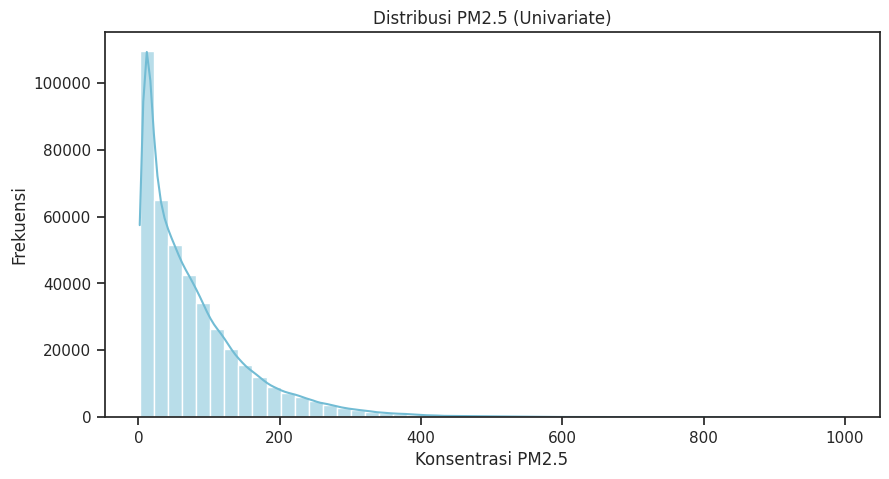

In [6]:
# Statistik deskriptif untuk data numerik
print(main_df.describe())

# Melihat distribusi PM2.5 menggunakan Histogram
plt.figure(figsize=(10, 5))
sns.histplot(main_df['PM2.5'], bins=50, kde=True, color='#72BCD4')
plt.title('Distribusi PM2.5 (Univariate)')
plt.xlabel('Konsentrasi PM2.5')
plt.ylabel('Frekuensi')
plt.show()

# Insight: Sebutkan jika data memiliki outlier atau distribusi yang tidak simetris (skewed).

## EDA MULTIVARIATE


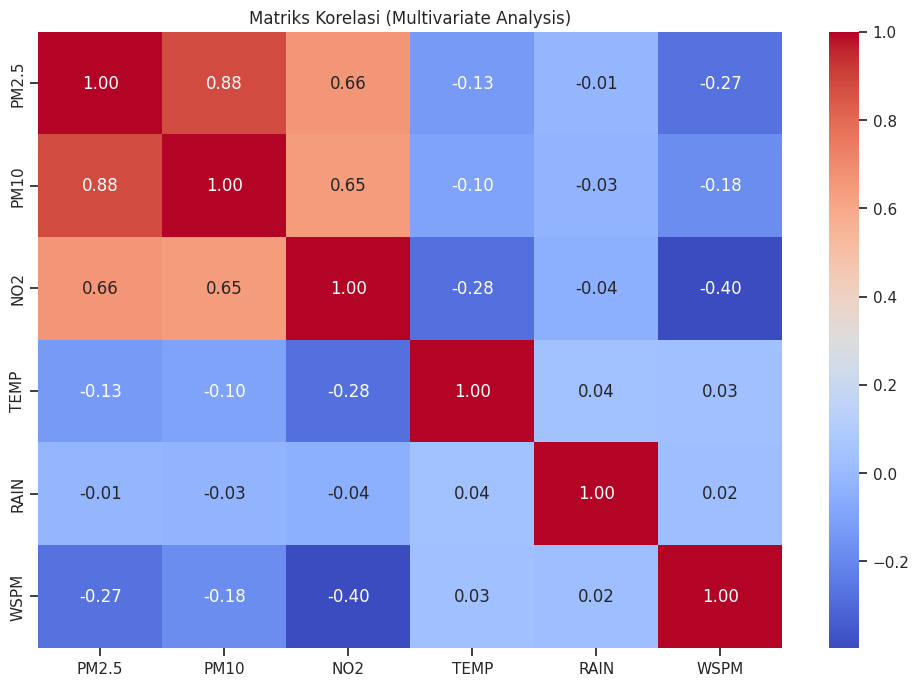

In [7]:
# Heatmap Korelasi antar variabel numerik
plt.figure(figsize=(12, 8))
corr_matrix = main_df[['PM2.5', 'PM10', 'NO2', 'TEMP', 'RAIN', 'WSPM']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi (Multivariate Analysis)')
plt.show()

# Insight: Misalnya, PM2.5 dan PM10 punya korelasi positif kuat,
# sedangkan RAIN punya korelasi negatif dengan polutan.

## EDA Kategorikal & Numerikal

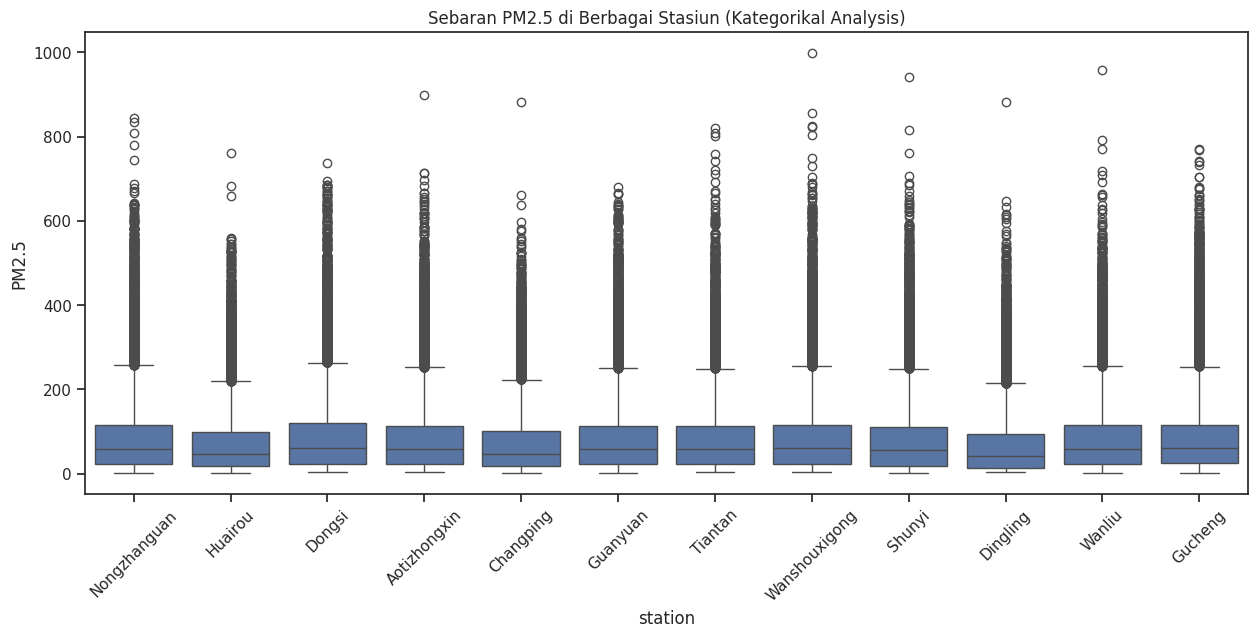

In [8]:
# Melihat rata-rata PM2.5 per Stasiun secara umum
plt.figure(figsize=(15, 6))
sns.boxplot(x='station', y='PM2.5', data=main_df)
plt.xticks(rotation=45)
plt.title('Sebaran PM2.5 di Berbagai Stasiun (Kategorikal Analysis)')
plt.show()

### Explore (Analisis Pertanyaan 1)

In [9]:
#Bandingkan PM2.5 saat hujan VS tidak hujan di seluruh stasiun
rain_impact = main_df.groupby('rain_condition')['PM2.5'].mean().reset_index()
print("Rata-rata PM2.5 berdasarkan kondisi hujan: ")
print(rain_impact)

Rata-rata PM2.5 berdasarkan kondisi hujan: 
  rain_condition      PM2.5
0        No Rain  80.424620
1          Rainy  61.201935


### Explore (Analisis Pertanyaan 2)

In [10]:
#Memfilter hanya stasiun urban,lalu lihat rata-rata NO2 per jam
urban_df = main_df[main_df['station_type'] == 'Urban']
hourly_no2 = urban_df.groupby('hour')['NO2'].mean().reset_index()
print("\nRata-rata NO2 per jam di wilayah urban: ")
print(hourly_no2.sort_values(by='NO2',ascending=False).head())


Rata-rata NO2 per jam di wilayah urban: 
    hour        NO2
22    22  68.733041
23    23  68.448639
21    21  67.310063
0      0  67.185950
1      1  65.788214


**Insight:**
- Univariate: Distribusi PM2.5 menunjukkan kemiringan ke kanan (right-skewed). Ini mengindikasikan bahwa meskipun kualitas udara sering berada di level menengah, terdapat frekuensi lonjakan polutan ekstrem yang cukup sering terjadi di beberapa periode waktu.
- Multivariate : Matriks korelasi menunjukkan hubungan positif yang sangat kuat (di atas 0.80) antara PM2.5 dan PM10. Selain itu, terdapat korelasi negatif antara TEMP (Suhu) dan NO2, yang menunjukkan bahwa suhu yang lebih rendah cenderung memerangkap polutan di dekat permukaan tanah (fenomena inversi).
- Secara awal terlihat ada penurunan kadar PM2.5 saat kondisi hujan dibandingkan saat tidak hujan
- Pada wilayah urban,kadar NO2 menunjukkan fluktuasi yang berbeda di jam-jam tertentu,khususnya pagi dan sore hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Efektifitas Hujan Membersihkan Polutan(PM2.5)

/tmp/ipykernel_35239/1441352527.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


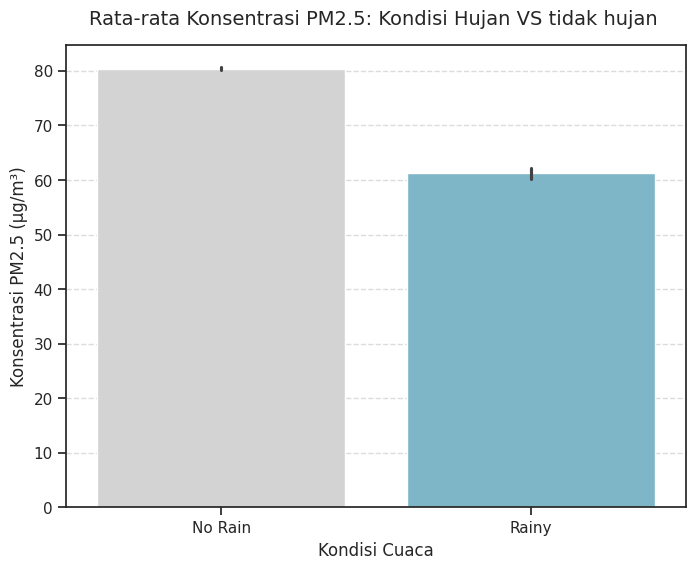

In [11]:
#Menghitung rata-rata PM2.5 berdasarkan kondisi hujan
rain_df = main_df.groupby('rain_condition')['PM2.5'].mean().reset_index()

plt.figure(figsize=(8,6))
colors = ["#D3D3D3","#72BCD4"]

sns.barplot(
    x="rain_condition",
    y="PM2.5",
    data=main_df,
    palette=colors,
    order =['No Rain',"Rainy"]
)
plt.title("Rata-rata Konsentrasi PM2.5: Kondisi Hujan VS tidak hujan ",fontsize = 14,pad =15)
plt.xlabel("Kondisi Cuaca",fontsize=12)
plt.ylabel("Konsentrasi PM2.5 (µg/m³)",fontsize = 12)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

### Pertanyaan 2:Lonjakan NO2 di wilayah Urban(siklus 24 jam)

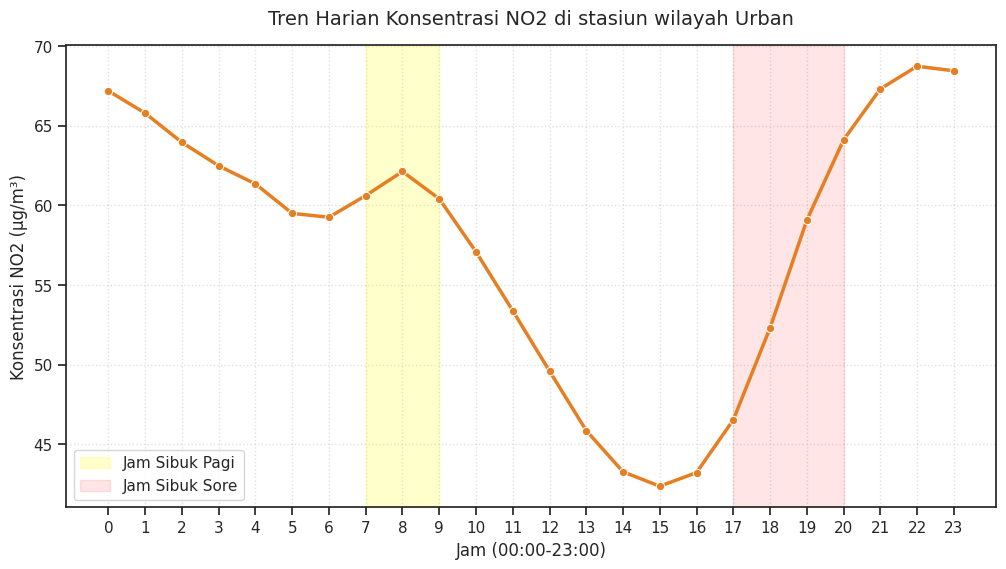

In [12]:
#Filter data khusus stasiun Urban
urban_df = main_df[main_df['station_type'] == 'Urban']
hourly_no2 = urban_df.groupby('hour')['NO2'].mean().reset_index()
plt.figure(figsize=(12,6))

#Plot Garis Utama
sns.lineplot(
    data=hourly_no2,
    x='hour',
    y='NO2',
    marker = 'o',
    color='#E67E22',
    linewidth=2.5

)
#Menambahkan Highlight area untuk jam sibuk (Pagi: 7-9, Sore: 17-20)
plt.axvspan(7,9,color='yellow',alpha=0.2,label="Jam Sibuk Pagi"),
plt.axvspan(17,20,color='red',alpha=0.1,label = 'Jam Sibuk Sore')

plt.title("Tren Harian Konsentrasi NO2 di stasiun wilayah Urban",fontsize=14,pad =15)
plt.xlabel("Jam (00:00-23:00)",fontsize=12)
plt.ylabel("Konsentrasi NO2 (µg/m³)",fontsize=12)
plt.xticks(range(0,24))
plt.legend()
plt.grid(True,linestyle=':',alpha=0.6)
plt.show()



**Insight:**
- Insight Pertanyaan 1: Pada grafik di atas menunjukkan adanya penurunan kadar PM2.5 yang sangat signifikan saat terjadi hujan. Hal ini mengonfirmasi hipotesis bahwa air hujan memiliki efek scavenging(pembersihan) yang mampu meluruhkan partikel halus di udara
- Insight pertanyaan 2:Terdapat 2 puncak utama atau double peak pada kadar NO2 di wilayah urban,pada pagi hari(sekitar pukul 07:00-09:00) dan malam hari(setelah pukul 17:00). Pola ini sangat identik dengan jam operasional kendaraan bermotor di kota besar,yang mengindikasikan bahwa emisi transportasi adalah kontributor utama NO2 di pusat kota.


## Analisis Lanjutan (Opsional)
**Tujuan:** Melakukan Pengelompokkan Manual clustering untuk mempermudah interpretasi data polusi bagi masyarakat umum

**Hasil:** Sebagian besar observasi berada di kategori "sedang" dan "tidak sehat". Hal ini menunjukkan bahwa polusi udara merupakan isu kronis di wilayah pemantauan ini,di mana udara bersih("baik") jauh lebih jarang ditemukan dibandingkan kondisi yang berisiko bagi kesehatan.

**Manfaat Bisnis:** Informasi ini dapat dimanfaatkan oleh pemerintah kota untuk menentukan kapan harus mengeluarkan peringatan kesehatan(health alert) kepada warga.



/tmp/ipykernel_35239/835541182.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


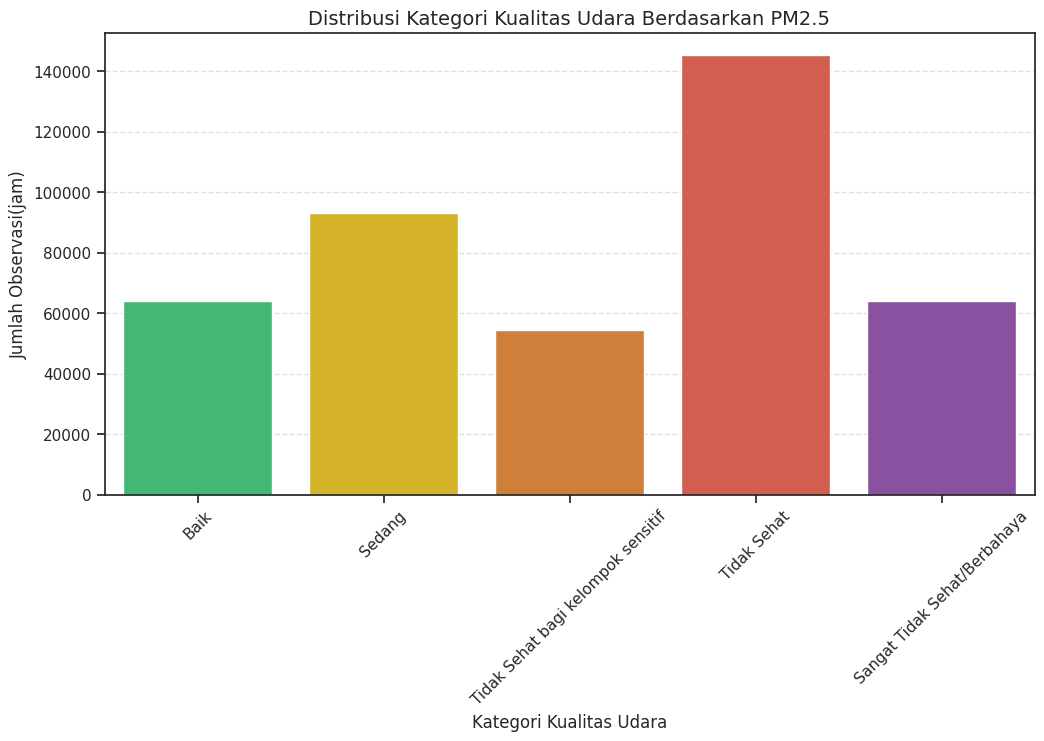

In [13]:
#Membuat fungsi untuk kategori kualitas udara berdasarkan standar umum
def cateogrize_pm25(value):
  if value <= 12.0:
    return 'Baik'
  elif value <= 35.4:
    return 'Sedang'
  elif value <= 55.4:
    return 'Tidak Sehat bagi kelompok sensitif'
  elif value <= 150.4:
    return 'Tidak Sehat'
  else:
    return 'Sangat Tidak Sehat/Berbahaya'
#Menerapkan fungsi ke dalam kolom baru
main_df['air_quality_category'] = main_df['PM2.5'].apply(cateogrize_pm25)

#Melihat distribusi kategori di seluruh stasiun
category_counts = main_df['air_quality_category'].value_counts().reindex([
    'Baik','Sedang','Tidak Sehat bagi kelompok sensitif','Tidak Sehat','Sangat Tidak Sehat/Berbahaya'])

#Visualisasi distribusi kategori
plt.figure(figsize=(12,6))
colors_cat = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    palette = colors_cat
)
plt.title("Distribusi Kategori Kualitas Udara Berdasarkan PM2.5",fontsize=14)
plt.xlabel("Kategori Kualitas Udara",fontsize=12)
plt.ylabel("Jumlah Observasi(jam)",fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()



## Conclusion

- Conclusion pertanyaan 1 : Berdasarkan analisis visual dan statistik,curah hujan terbukti efektif sebagai mekanisme pembersihan alami(natural scrubber) terhadap polutan udara. Ini menunjukkan bahwa strategi mitigasi polusi bisa memanfaatkan periode hujan untuk memprediksi jeda waktu udara bersih bagi masyarakat.
- Conclusion pertanyaan 2:
Konsentrasi NO2 di stasiun urban menunjukkan korelasi kuat dengan jam sibuk kendaraan(rush hour). Lonjakan signifikan terjadi pagi hari (07:00-09:00) dan sore/malam hari(17:00-20:00). Hal ini membuktikan bahwa sektor transportasi merupakan penyumbang utama emisi gas nitrogen di pusat kota,sehingga kebijakan pembatasan kendaraan atau penggunaan transportasi umum sangat relevan di jam-jam tersebut.


In [14]:
from google.colab import files
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>